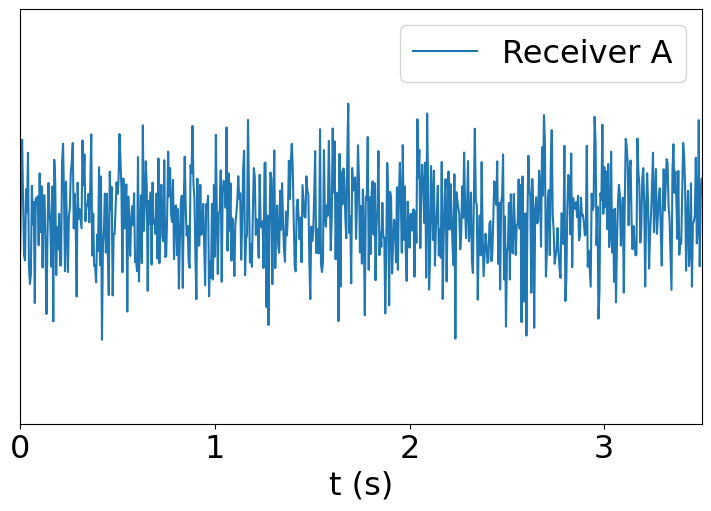

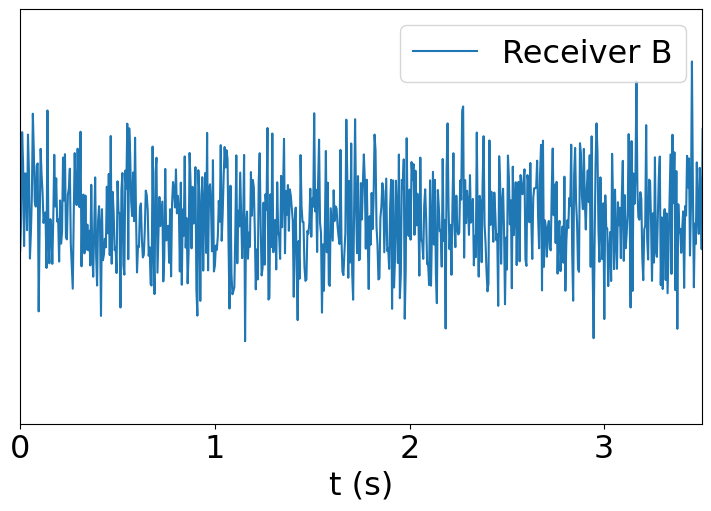

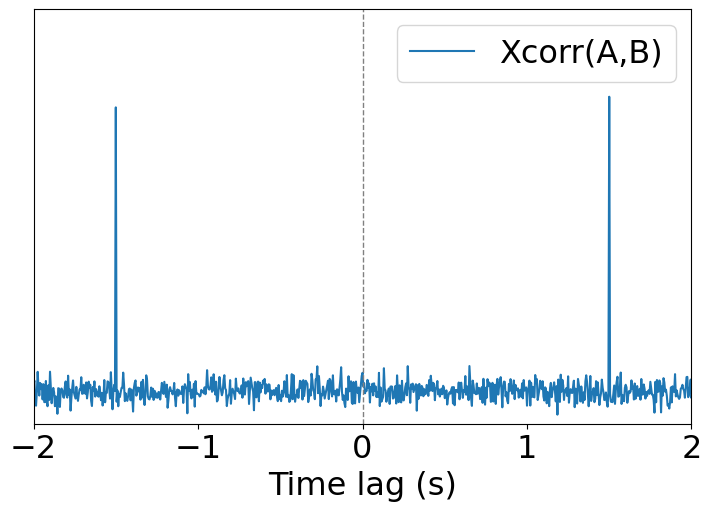

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

# --- parameters --------------------------------------------------------------
fs       = 200.0           # sample rate [Hz]
T        = 30.0             # record length [s]
t        = np.arange(0, T, 1/fs)
n        = t.size
tau      = 1.5             # physical propagation time [s]
n_shift  = int(tau * fs)   # shift in samples

#np.random.seed(0)          # reproducible noise

# two *independent* noise fields: one propagating →, one ←
R = np.random.normal(0, 0.3, n)           # right‑propagating field
L = np.random.normal(0, 0.3, n)           # left‑propagating  field


# recordings at two stations A (x=0) and B (x=d)
# R arrives at A first, L arrives at B first
trA = R + np.roll(L,  n_shift)            # L delayed at A
trB = np.roll(R, n_shift) + L             # R delayed at B

# cross‑correlation (full) and symmetric stack
xc1    = np.correlate(trA, trB, mode='full')
xc2    = np.correlate(trB, trA, mode='full')
#xc_sym = 0.5 * (xc1 + xc2)
lags   = np.arange(-n + 1, n) / fs
#xc_sym /= np.abs(xc_sym).max()


# === Trace A ===
plt.rcParams.update({'font.size': 23})
fig, ax = plt.subplots(figsize=(7,5), constrained_layout=True)
ax.plot(t, trA, label = "Receiver A")
ax.set_xlim(0, 3.5)
ax.set_xlabel('t (s)')
plt.ylim(-2, 2)
ax.set_xticks(np.arange(0, 4, 1))                 # integer ticks 0,1,2,3
ax.set_yticks([])                                 # no y tick labels
plt.legend(loc = "upper right")
plt.show()

# === Trace B ===
fig, ax = plt.subplots(figsize=(7,5), constrained_layout=True)
ax.plot(t, trB, label = "Receiver B")
ax.set_xlim(0, 3.5)
plt.ylim(-2, 2)
ax.set_xlabel('t (s)')
ax.set_xticks(np.arange(0, 4, 1))
ax.set_yticks([])
plt.legend(loc = "upper right")
plt.show()

# === Cross-correlation ===
fig, ax = plt.subplots(figsize=(7,5), constrained_layout=True)
ax.plot(lags, xc1, label="Xcorr(A,B)")
ax.set_xlim(-2, 2)                                # show both ±1.5 s peaks
ax.set_xlabel('Time lag (s)')
ax.set_ylim(np.min(xc1-5), np.max(xc1)+150)
ax.set_yticks([])
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
plt.legend(loc = "upper right")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


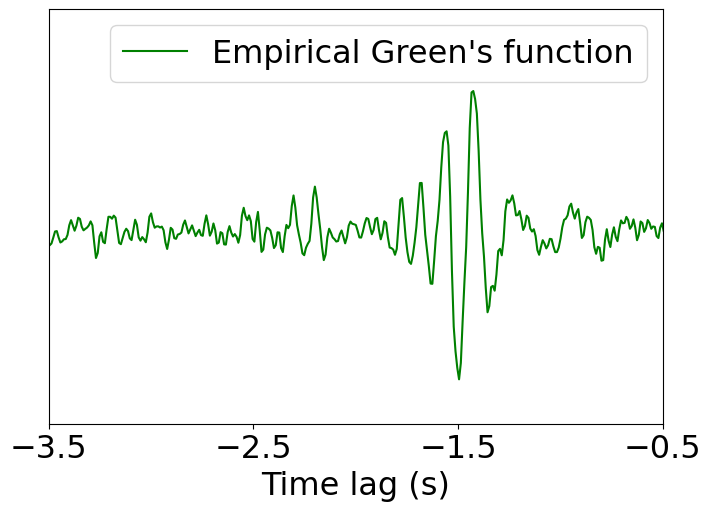

In [3]:
import netCDF4 as nc # type: ignore

path = f"./STACKS2/01/REF/ZZ/XA.G3.--_XA.G4.--.nc"
st_combi = []
cc_dat_ref_list, cc_dat_ref_sym_list, time_list = [], [], []

with nc.Dataset(path) as st_ref:
    cc_ref = st_ref.variables['CCF'][:]
    ax_ref = st_ref.variables['taxis'][:]
    cc_ref_sym = (cc_ref + np.flip(cc_ref)) / 2

    cc_dat_ref_list.append(cc_ref)
    cc_dat_ref_sym_list.append(cc_ref_sym)
    time_list.append(ax_ref)

neg_min, neg_max = 13380, 13750
pos_min, pos_max = 13870, 14210



segment = cc_dat_ref_list[0][neg_min:neg_max]
segment_lag = time_list[0][neg_min:neg_max]

segment_plot = segment/np.abs(np.min(segment))

plt.rcParams.update({'font.size': 23})
plt.figure(figsize=(7,5), constrained_layout=True)
plt.xlim(-3.5, -0.5)
plt.plot(segment_lag, segment_plot, color = 'g', label="Empirical Green's function")
plt.xlabel('Time lag (s)')
plt.ylim(-1.3,1.5)
plt.yticks([])  
ax = plt.gca()
plt.xticks([-0.5, -1.5, -2.5, -3.5])
plt.legend(loc='upper right')
plt.savefig("empGreen.eps", dpi=1000)
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


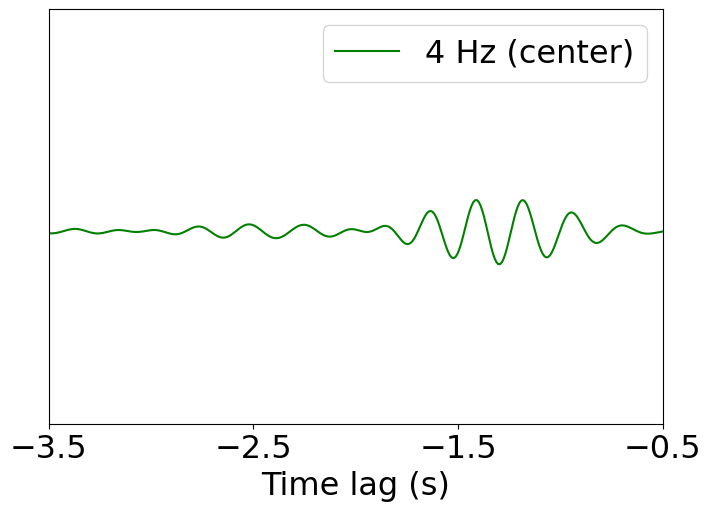

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


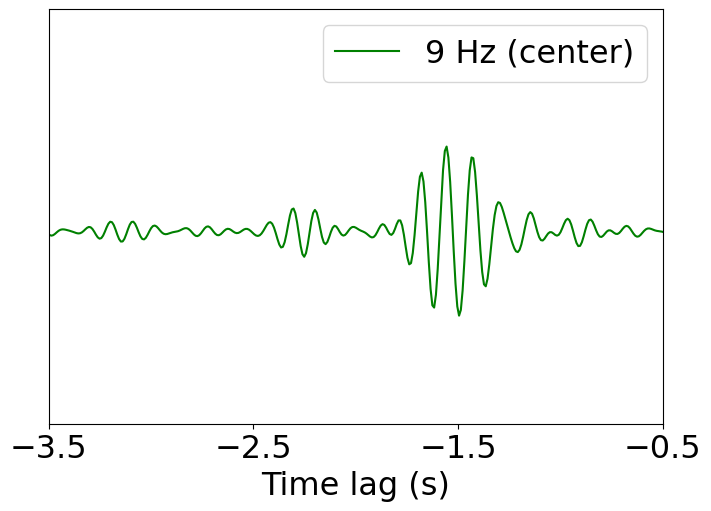

In [ ]:
from obspy.signal.tf_misfit import cwt
import scipy.signal as sig

sampling = 115
dt = 1 / sampling  # Time step
w0=6
fmin = 3.6
fmax = 11.4
nf = 50

scalogram, scales = cwt(segment, dt, w0, fmin, fmax, nf)
freq_test = w0/(2*np.pi*scales)


freq_filter = 4
sos = sig.butter(4, [freq_filter-1, freq_filter+1], btype='bandpass', fs=sampling, output='sos')
band = sig.sosfiltfilt(sos, segment)

band = band/np.abs(np.min(segment))

plt.rcParams.update({'font.size': 23})
plt.figure(figsize=(7,5), constrained_layout=True)
plt.plot(segment_lag, band, color = 'g', label='4 Hz (center)')
plt.xlim(-3.5, -0.5)
plt.xlabel('Time lag (s)')
plt.ylim(-1.3,1.5)
plt.yticks([])  
ax = plt.gca()
plt.xticks([-0.5, -1.5, -2.5, -3.5])#
plt.legend(loc='upper right')
plt.show()

freq_filter = 9
sos = sig.butter(4, [freq_filter-2.5, freq_filter+2.5], btype='bandpass', fs=sampling, output='sos')
band = sig.sosfiltfilt(sos, segment)

band = band/np.abs(np.min(segment))

plt.figure(figsize=(7,5), constrained_layout=True)
plt.plot(segment_lag, band, color = 'g', label='9 Hz (center)')
plt.xlim(-3.5, -0.5)
plt.xlabel('Time lag (s)')
plt.ylim(-1.3,1.5)
plt.yticks([])  
ax = plt.gca()
plt.xticks([-0.5, -1.5, -2.5, -3.5])
plt.legend(loc='upper right')
plt.show()

/tmp/ipykernel_1549132/2627542955.py:41: RuntimeWarning: divide by zero encountered in divide
  lambda v: -56.9/v                 # v → τ
/tmp/ipykernel_1549132/2627542955.py:30: RuntimeWarning: divide by zero encountered in divide
  lambda f: w0/(2*np.pi*f)))       # Hz     ➜  scale (needed for zoom/pan)


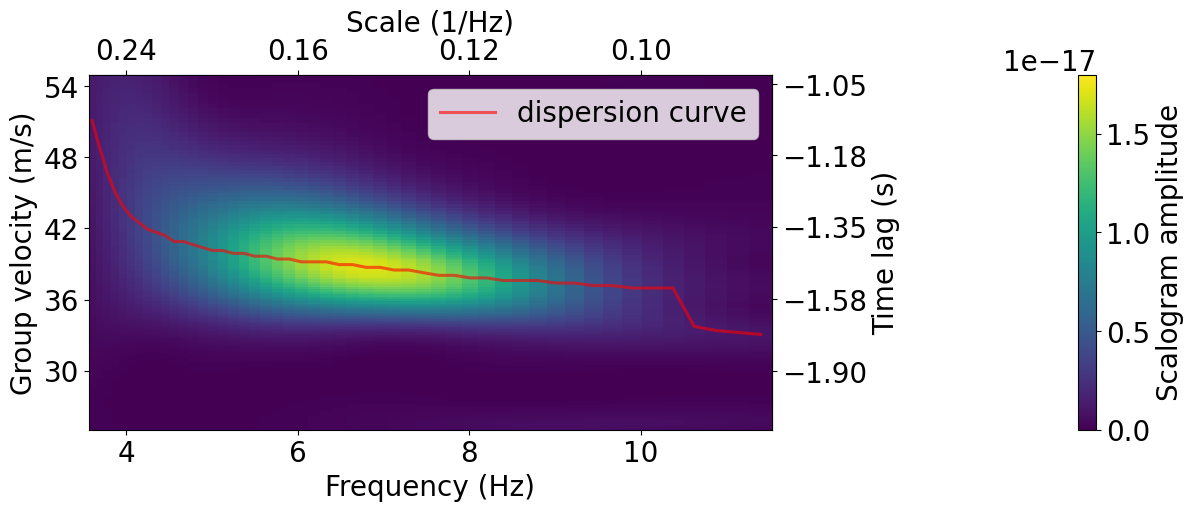

In [6]:
from obspy.imaging.cm import obspy_sequential
scal = np.abs(scalogram)**2
color_val = np.transpose(scal)

vel = 56.9 / np.abs(segment_lag)
freq = freq_test
freq_ax, vel_ax2 = np.meshgrid(freq, vel)

# create figure & axes
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

# draw the scalogram; pass through vmin/vmax
pcm = ax.pcolormesh(
    freq_ax,
    vel_ax2,
    color_val,
    cmap=obspy_sequential,
    vmin=0,
    vmax=1.8e-17
)

# axes labels and limits
ax.set_xlabel("Frequency (Hz)", fontsize=20)
ax.set_ylabel("Group velocity (m/s)", fontsize=20)

secax = ax.secondary_xaxis(
    'top',
    functions=(lambda s: w0/(2*np.pi*s),        # scale  ➜  Hz
               lambda f: w0/(2*np.pi*f)))       # Hz     ➜  scale (needed for zoom/pan)
secax.set_xlabel('Scale (1/Hz)', fontsize=20)
secax.set_xticks(w0/(2*np.pi*np.array([4,6,8,10])))
secax.xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: f"{val:.2f}")
)

secay = ax.secondary_yaxis(
    'right',
    functions=(
        lambda tau: -56.9/np.abs(tau) ,     # τ → v
        lambda v: -56.9/v                 # v → τ
    )
)
secay.set_ylabel('Time lag (s)', fontsize=20)
secay.yaxis.set_major_locator(MaxNLocator(nbins=5))
secay.set_yticks([-1.05,-1.18, -1.35, -1.58, -1.9])

imax = np.nanargmax(color_val, axis=0)    # shape (n_freqs,)

# 2) convert lag‐indices to velocities
max_curve = vel[imax]                     # shape (n_freqs,)

# 3) overplot on top of your pcolormesh
ax.plot(freq, max_curve,
        color='red',
        alpha=0.6,
        linewidth=2.2,
        label='dispersion curve')

ax.legend(loc='upper right', fontsize=20)

#ax.set_xlim(fmin, fmax)
ax.set_ylim(25, 55)
plt.yticks([30, 36, 42, 48, 54])

# tick formatting
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# add the colorbar
cbar_label="Scalogram amplitude"
cbar = fig.colorbar(pcm, ax=ax, pad=0.15)
cbar.set_label(cbar_label, fontsize=20)
cbar.ax.tick_params(labelsize=20)